<a href="https://colab.research.google.com/github/rajukarki467/Data-Science-projects/blob/main/FakeNewsDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # **Fake News Detection — Data Science Project**

*MSc in Informatics and Intelligent Systems Engineering*

Institute: Thapathali Campus, IOE, Tribhuvan University

Course: Data Science and Modeling



* Student: Raju Karki
* Roll No: MSISE012

# Import Libraries
* IMPORT ALL REQUIRED LIBRARIES

In [25]:
# Core data libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
#standard libraries
import re # for regural expression
import string
import warnings
warnings.filterwarnings('ignore')

NLP - natural language Processing

In [27]:
import nltk
nltk.download('stopwords',quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [28]:
# Feature Engineering
from sklearn.feature_extraction.text import(
    TfidfTransformer,
    CountVectorizer,
    TfidfVectorizer
)

In [29]:
# machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

In [30]:
# Model Selection and Cross-Validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

**Evaluation Matrics:**

1. These mtrix helps us to evaluate the perfomance/goodness/correctness of the classification models

2. On the basis of these metrics i can compare a different model and tell which model perform better


In [31]:
# Evaluation Metrics
import sklearn.metrics as metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)


In [32]:
# model persistence
import joblib

In [33]:
print("All libraries imported sucessfully.")
print(f"Numpy :{np.__version__}")
print(f"Pandas: {pd.__version__}")
import sklearn
print(f' Sklearn : {sklearn.__version__}')

All libraries imported sucessfully.
Numpy :2.0.2
Pandas: 2.2.2
 Sklearn : 1.6.1


#Load Dataset

 **Files required:** `True.csv` and `Fake.csv` (place in same directory as this notebook)

| File | Content | Source |
|---|---|---|
| `True.csv` | Real news articles | Reuters, politicsNews, worldnews |
| `Fake.csv` | Fake news articles | Conspiracy, Government News, tabloids |

# Read the dataset using read_csv-
*  engine='python'       : handles complex CSV encoding
*  quotechar='"'         : standard double-quote delimiter
*  doublequote=True      : handles escaped quotes inside fields
*  on_bad_lines='skip'   : skip malformed rows gracefully

In [34]:
true_news = pd.read_csv(
    '/content/True.csv',
    engine='python',
    quotechar='"',
    doublequote=True,
    on_bad_lines='skip'
)

fake_news = pd.read_csv(
    '/content/Fake.csv',
    engine='python',
    quotechar='"',
    doublequote=True,
    on_bad_lines='skip'
)

 # Exploratory Data Analysis (EDA):
* Exploring both datasets to understand structure, statistics, and distributions before cleaning.

In [35]:
print(f"Datasets loaded sucessfully.")
print(f"true news shape  :  {true_news.shape}")
print(f"Fake news shape  :  {fake_news.shape}")
print(f"Columns          :  {true_news.columns.tolist()}")
print(f"Columns          :  {fake_news.columns.tolist()}")

Datasets loaded sucessfully.
true news shape  :  (21417, 4)
Fake news shape  :  (23481, 4)
Columns          :  ['title', 'text', 'subject', 'date']
Columns          :  ['title', 'text', 'subject', 'date']


# 1. EXPLORE TRUE NEWS DATASET

In [36]:
# Show top 5 rows of the data for basic information
print("Top 5 rows of True News:")
true_news.head()

Top 5 rows of True News:


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [37]:
# Knowing the dataset shape
print(" True News shape (rows, columns):")
print(true_news.shape)

 True News shape (rows, columns):
(21417, 4)


In [38]:
# Show the last 5 rows
print("Last 5 rows of True News:")
true_news.tail()

Last 5 rows of True News:


,title,text,subject,date
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017"


* Basic statistics: count, unique, top, freq for categorical;
* count, mean, std, min, max for numerical

In [39]:
print("True News — Basic Statistics:")
true_news.describe(include='all')

True News — Basic Statistics:


,title,text,subject,date
count,21417,21417,21417,21417
unique,20826,21192,2,716
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"December 20, 2017"
freq,14,8,11272,182


Checking data basic info:
* gives detail of memory consumption, datatypes,
*  total number of rows, column names, and null value count

In [40]:

print(" True News — Info (dtypes, memory, null counts):")
true_news.info()

 True News — Info (dtypes, memory, null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [41]:
# Showing total count of datasets (non-null values per column)
print("rue News — Column-wise non-null count:")
print(true_news.count())

rue News — Column-wise non-null count:
title      21417
text       21417
subject    21417
date       21417
dtype: int64


# 2.  EXPLORE FAKE NEWS DATASET

In [42]:
print(" Top 5 rows of Fake News:")
fake_news.head()

 Top 5 rows of Fake News:


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [43]:
# Show the last 5 rows
print("Last 5 rows of Fake News:")
fake_news.tail()

Last 5 rows of Fake News:


,title,text,subject,date
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016"


In [44]:
# Shape of fake news dataset
print("Fake News shape (rows, columns):")
print(fake_news.shape)

Fake News shape (rows, columns):
(23481, 4)


In [45]:
# Basic statistics of fake news data
print("Fake News — Basic Statistics:")
fake_news.describe(include='all')

Fake News — Basic Statistics:


,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


In [46]:
# Data info of fake news
print("Fake News — Info (dtypes, memory, null counts):")
fake_news.info()

Fake News — Info (dtypes, memory, null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [47]:
# Count of fake news columns
print("Fake News — Column-wise non-null count:")
print(fake_news.count())

Fake News — Column-wise non-null count:
title      23481
text       23481
subject    23481
date       23481
dtype: int64


# CLASS BALANCE OBSERVATION

In [48]:
print(f"True news records  : {len(true_news):,}")
print(f"Fake news records  : {len(fake_news):,}")
print()

True news records  : 21,417
Fake news records  : 23,481



# Observation:
  * True = 21,417  
  *   Fake = 23,500
  # Analysis:
  * Dataset is near-balanced — no class imbalance handling needed.
  (SMOTE, class_weight adjustment are NOT required.)
  * We can able to evaluate a model based on the accuracy  of the model

# Data Cleaning:
Handling missing values and duplicate records is necessary because:


  1. Proper handling of missing values increases model correctness

  2. Improves model performance

  3. Removes errors that could cause training failures

  4. Duplicate removal prevents data leakage between train/test sets and reduces overfitting

# Handle Missing Values
Checks and reports missing values per column.

    Mathematical basis:
        Missing percentage = (missing_count / total_rows) × 100

Importance of handling missing data:

  1. Proper handling increases model correctness

  2. Improves model performance

  3. Removes errors from NaN propagation
  
  4. Enables faster model convergence

In [49]:
def find_missing_data(data,dataset_name):
  print("="*40)
  print(f"Missing  Value  Report -{dataset_name}")
  print("="*40)

  total = len(data)
  for column in data.columns:
    missing_count = data[column].isna().sum()
    if missing_count != 0:
      pct=(missing_count /total)*100
      print(f"{column} :{missing_count:,}({pct:.2f})% missing values")
    else:
      print(f" {column}: no missing values")

  print(f"\n <Missing Value Summary")
  print("-"*40)
  print(data.isnull().sum(axis=0))

# Missing Summary of True News

In [50]:
find_missing_data(true_news,"True News")

Missing  Value  Report -True News
 title: no missing values
 text: no missing values
 subject: no missing values
 date: no missing values

 <Missing Value Summary
----------------------------------------
title      0
text       0
subject    0
date       0
dtype: int64


# Missing Summary of Fake News

In [51]:
find_missing_data(fake_news,"Fake News")

Missing  Value  Report -Fake News
 title: no missing values
 text: no missing values
 subject: no missing values
 date: no missing values

 <Missing Value Summary
----------------------------------------
title      0
text       0
subject    0
date       0
dtype: int64


# Handling Duplicate Values
* Removes duplicate rows from the dataset.
    Retains first occurrence (keep='first').

 Handling duplicates is necessary because:
    
  1. Removing duplicates makes model convergence cleaner

  2. Prevents overfitting by reducing memorisation risk

  3. Prevents data leakage (same article in train AND test)
  
  4. Makes training faster (fewer redundant samples)

      

      

      

     

In [52]:
def remove_duplicates(data,dataset_name):
  print("*"*35)
  print(f'Cleaning SUmmary -{dataset_name}')
  print("*"*35)
  size_before = len(data)
  data.drop_duplicates(subset=None,keep='first',inplace=True)
  size_after = len(data)
  removed = size_before - size_after
  print(f"Rows Before :{size_before}")
  print(f"Rows After  :{size_after}")
  print(f"Removed     :{removed:,} duplicate rows")


**Summary of Duplicates Rows in True News**

In [53]:
remove_duplicates(true_news,"True News")

***********************************
Cleaning SUmmary -True News
***********************************
Rows Before :21417
Rows After  :21211
Removed     :206 duplicate rows


**Summary of Duplicate Rows in Fake News**

In [54]:
remove_duplicates(fake_news,"Fake News")

***********************************
Cleaning SUmmary -Fake News
***********************************
Rows Before :23481
Rows After  :23478
Removed     :3 duplicate rows


# ASSIGN LABELS AND MERGE

After checking both individually, assign binary labels:
*  label = 1  →  True (real) news
*  label = 0  →  Fake news

In [55]:
fake_news['label'] = 0
true_news['label'] = 1

print("▶ Labels assigned:")
print("   True news  →  label = 1")
print("   Fake news  →  label = 0")

▶ Labels assigned:
   True news  →  label = 1
   Fake news  →  label = 0


*  Merge both datasets into a single table (outer join = union)
*  Here both tables combine vertically, one after another
* so total number of data increases
* We make a single dataset so that we can train a model on it


In [56]:
df_train = pd.merge(fake_news,true_news,how='outer')
print(df_train.head(2))

                                               title  \
0  \r\r\r\r\r\r\r\nDonald Trump Gets His A** Hand...   
1  \r\r\r\r\r\r\r\nEx-GOP Congressman Shreds Fell...   

                                                text subject  \
0  A 10-year-old girl smacked down Donald Trump, ...    News   
1  At this point, every Republican who refuses to...    News   

                date  label  
0  February 29, 2016      0  
1      June 22, 2017      0  


In [57]:
df_train.reset_index(drop=True,inplace=True)
print(df_train.head(2))

                                               title  \
0  \r\r\r\r\r\r\r\nDonald Trump Gets His A** Hand...   
1  \r\r\r\r\r\r\r\nEx-GOP Congressman Shreds Fell...   

                                                text subject  \
0  A 10-year-old girl smacked down Donald Trump, ...    News   
1  At this point, every Republican who refuses to...    News   

                date  label  
0  February 29, 2016      0  
1      June 22, 2017      0  


In [58]:
print(f"Merged dataset shape : {df_train.shape}")
print(f"Top 5 rows of merged dataset: ")
df_train.head()

Merged dataset shape : (44689, 5)
Top 5 rows of merged dataset: 


,title,text,subject,date,label
0,\r\r\r\r\r\r\r\nDonald Trump Gets His A** Hand...,"A 10-year-old girl smacked down Donald Trump, ...",News,"February 29, 2016",0
1,\r\r\r\r\r\r\r\nEx-GOP Congressman Shreds Fell...,"At this point, every Republican who refuses to...",News,"June 22, 2017",0
2,\r\r\r\r\r\r\r\nTrump Gets STOMPED For Whining...,Donald Trump has been attacking President Obam...,News,"November 5, 2016",0
3,\r\r\r\r\r\r\r\nWATCH: Democratic Rep Delivers...,Massachusetts Rep. Jim McGovern brought the Ho...,News,"May 4, 2017",0
4,#AfterTrumpImplodes Hashtag Hilariously Imagi...,What will the world be like post-Donald Trump?...,News,"August 5, 2016",0


# Label(Target) distribution of merged dataset

1. Knowing the distribution of the **target variable** helps in selecting appropriate evaluation metrics.
2. This ensures we can accurately assess model performance and take necessary steps to address any imbalances or biases in the target distribution.

In [62]:
print(" Label(Traget) sidtribution in merged dataset: ")
print("-"*50)
print(df_train['label'].value_counts())
print()

 Label(Traget) sidtribution in merged dataset: 
--------------------------------------------------
label
0    23478
1    21211
Name: count, dtype: int64



In [64]:
print("Label balance (%):")
print(df_train['label'].value_counts(normalize=True).mul(100).round(2))
print()

Label balance (%):
label
0    52.54
1    47.46
Name: proportion, dtype: float64



Visually Showing the Target Distribution

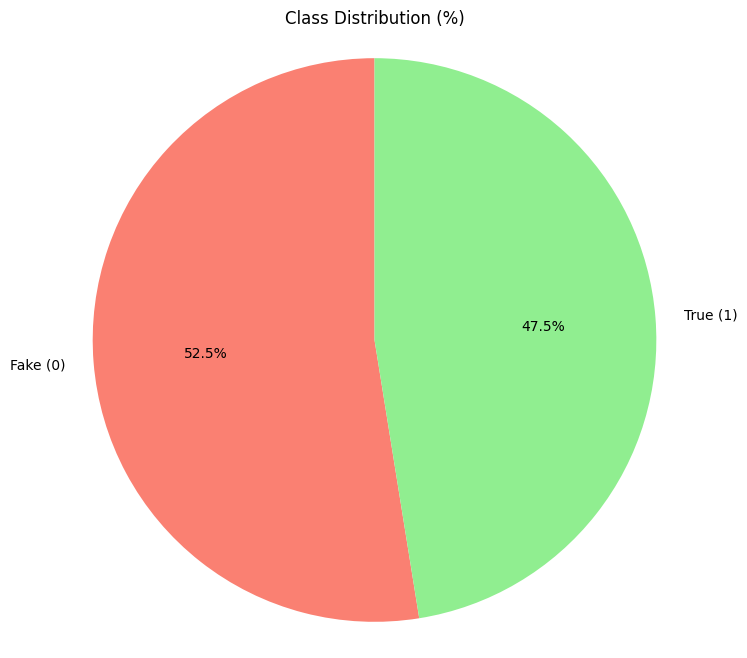

In [71]:
#Get class counts
class_count = df_train['label'].value_counts()

#--piechart---
plt.figure(figsize=(8,8))
plt.pie(class_count,labels=['Fake (0)', 'True (1)'] ,autopct ="%1.1f%%",startangle =90,colors=['salmon','lightgreen'])
plt.title('Class Distribution (%)')
plt.axis('equal') # Equal aspect ratio ensure that pie is drawn as a circle
plt.show()

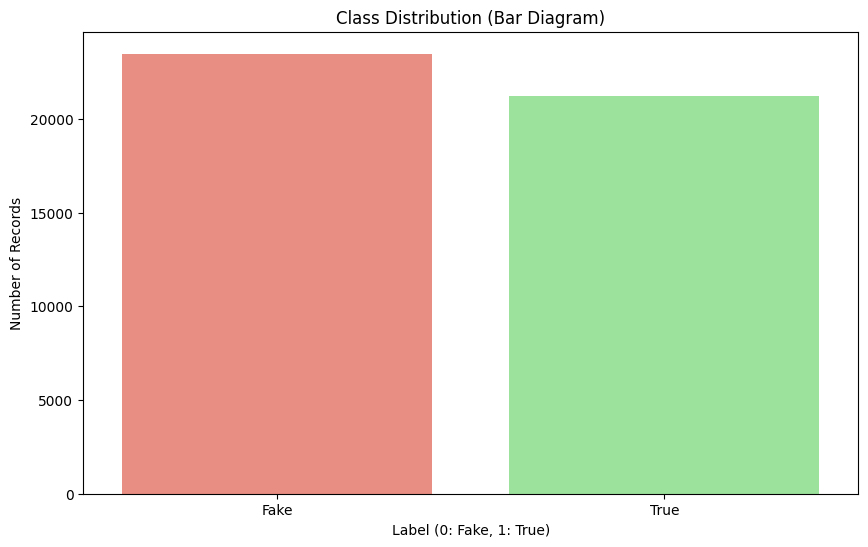

In [70]:

# -- Bar Diagram---
plt.figure(figsize =(10,6))
sns.countplot(x='label',data= df_train,palette ={0 : 'salmon' ,1: 'lightgreen'}, hue = 'label',legend =False)
plt.title('Class Distribution (Bar Diagram)')
plt.xlabel('Label (0: Fake, 1: True)')
plt.ylabel('Number of Records')
plt.xticks(ticks=[0, 1], labels=['Fake', 'True'])
plt.show()

* From this analysis, I can confirm that my dataset is almost balanced.



## Title word length EDA

▶ Title word length statistics by class:
         count   mean   std  min   25%   50%   75%   max
label                                                   
0      23478.0  14.73  4.34  1.0  12.0  14.0  17.0  42.0
1      21211.0   9.95  1.70  4.0   9.0  10.0  11.0  20.0


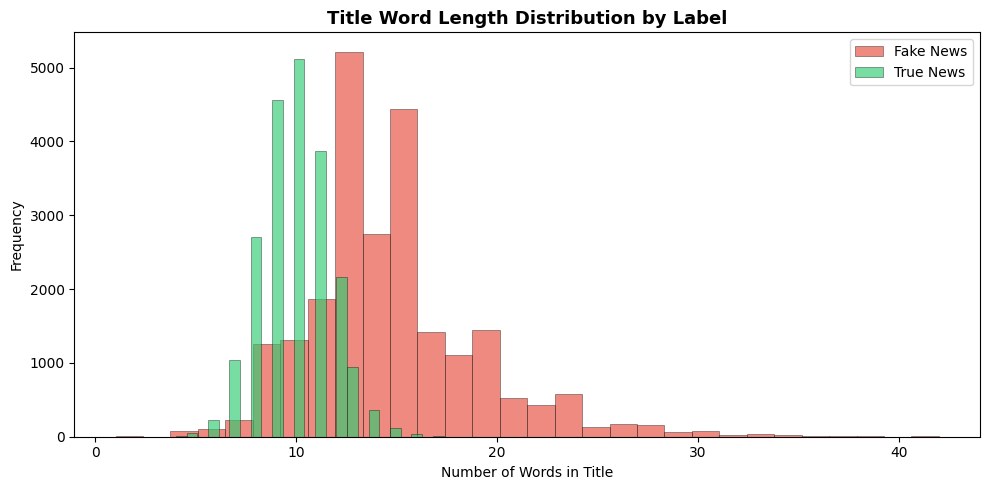

In [76]:
df_train['title_len'] = df_train['title'].apply(lambda x: len(str(x).split()))

print("Title word length statistics by class:")
print(df_train.groupby('label')['title_len'].describe().round(2))

fig, ax = plt.subplots(figsize=(10, 5))
for lbl, color, name in [(0,'#E74C3C','Fake'),(1,'#2ECC71','True')]:
    ax.hist(df_train[df_train['label']==lbl]['title_len'],
            bins=30, alpha=0.65, color=color,
            label=f'{name} News', edgecolor='black', linewidth=0.4)
ax.set_title('Title Word Length Distribution by Label',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Words in Title')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

## Text Preprocessing (Remove Stopwords & Punctuation)


### Mathematical Formulation — TF-IDF
$$\text{TF}(t, d) = \frac{f(t,d)}{\sum_{t'} f(t',d)}$$

$$\text{IDF}(t, D) = \log\left(\frac{N}{|\{d \in D : t \in d\}|}\right) + 1$$

$$\text{TF-IDF}(t,d,D) = \text{TF}(t,d) \times \text{IDF}(t,D)$$

With `sublinear_tf=True`: $\text{TF} = 1 + \log(f(t,d))$ to reduce dominance of high-frequency terms.

**Stopwords** are function words (the, a, is, at...) with no discriminative signal — removing them reduces dimensionality.  
**Porter Stemming** reduces words to root forms: *"secretly"* → *"secret"*, *"elections"* → *"elect"*

### TEXT PREPROCESSING PIPELINE

In [80]:
stop = set(stopwords.words('english'))
# Stemmer is no longer needed, using lemmatizer instead
# stemmer = PorterStemmer()
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
lemmatizer = WordNetLemmatizer()

 ### Full NLP text preprocessing pipeline:

    Step 1: Lowercase — ensures vocabulary consistency
            e.g. 'Trump' and 'trump' become same token

    Step 2: Remove punctuation — strips .,!?;: etc.

    Step 3: Remove non-alphabetic characters

    Step 4: Tokenise, remove stopwords, apply WordNet Lemmatization
            Lemmatization reduces words to their base or dictionary form (lemma) while preserving meaning:
            'running' → 'run'
            'elections' → 'election'
            'secretly' → 'secret'
            'government' → 'government'

In [81]:
def preprocess_text(text):
  # step 1 : Lowercase
  text = str(text).lower()

  # step 2 : remove punctuation
  # This line seems to be collecting punctuation characters, not removing them.
  # It should be corrected to remove punctuation.
  text = ''.join([char for char in text if char not in string.punctuation])

  # step3 : Remove non-alphabetic characters
  text = re.sub(r'[^a-z\s]','',text)

  # step 4: Tokenize  + stopword removal + lemmatization
  token = [
      lemmatizer.lemmatize(word)
      for word in text.split()
      if word not in stop and len(word) > 2
  ]
  return ' '.join(token)

In [85]:
print(" Apply the preprocessing function(Pipeline) to 'text' and 'title' columns")
print()
print("-"*30)
print()
df_train['clean_text'] = df_train['text'].apply(preprocess_text)
df_train['clean_title'] = df_train['title'].apply(preprocess_text)
print("Preprocessing complete. New columns 'clean_text' and 'clean_title' have been added.")
print("Displaying the first 5 rows with the new clean text and title:")
print(df_train[['title', 'clean_title', 'text', 'clean_text']].head())

 Apply the preprocessing function(Pipeline) to 'text' and 'title' columns

------------------------------

Preprocessing complete. New columns 'clean_text' and 'clean_title' have been added.
Displaying the first 5 rows with the new clean text and title:
                                               title  \
0  \r\r\r\r\r\r\r\nDonald Trump Gets His A** Hand...   
1  \r\r\r\r\r\r\r\nEx-GOP Congressman Shreds Fell...   
2  \r\r\r\r\r\r\r\nTrump Gets STOMPED For Whining...   
3  \r\r\r\r\r\r\r\nWATCH: Democratic Rep Delivers...   
4   #AfterTrumpImplodes Hashtag Hilariously Imagi...   

                                         clean_title  \
0         donald trump get handed yearold girl video   
1  exgop congressman shred fellow republican howl...   
2  trump get stomped whining president obama usin...   
3  watch democratic rep delivers scathing rebuke ...   
4  aftertrumpimplodes hashtag hilariously imago h...   

                                                text  \
0  A 10-year-old

In [86]:
print("\nSample — Before vs After Preprocessing:")
print("-" * 65)
for i in range(3):
    print(f"  BEFORE: {df_train['title'].iloc[i]}")
    print(f"  AFTER : {df_train['clean_title'].iloc[i]}")
    print()


Sample — Before vs After Preprocessing:
-----------------------------------------------------------------



  AFTER : donald trump get handed yearold girl video




  AFTER : exgop congressman shred fellow republican howling trump impeachment video




  AFTER : trump get stomped whining president obama using air force one campaign trail

